In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
%matplotlib widget

In [2]:
target_x = 1
target_y = 1
target_z = 1

In [3]:
with open("../output/test.json") as datafile:
    data = json.loads(datafile.read())
data = data['data']

In [4]:
df = pd.json_normalize(data)
df.head()

,timestep,datapoint.position.x,datapoint.position.y,datapoint.position.z,datapoint.velocity.x,datapoint.velocity.y,datapoint.velocity.z,datapoint.acceleration.x,datapoint.acceleration.y,datapoint.acceleration.z,datapoint.mass
0,0.00,0.000000e+00,0.000000e+00,0.000,0.000000e+00,0.000000e+00,0.2,0.000000e+00,0.000000e+00,0.000000,1
1,0.01,0.000000e+00,0.000000e+00,0.002,0.000000e+00,0.000000e+00,0.2,6.008797e-08,6.008797e-08,-0.000001,1
2,0.02,0.000000e+00,0.000000e+00,0.004,6.008797e-10,6.008797e-10,0.2,4.974159e-04,4.974159e-04,0.000004,1
3,0.03,6.008797e-12,6.008797e-12,0.006,4.974760e-06,4.974760e-06,0.2,4.971774e-04,4.971774e-04,0.000003,1
4,0.04,4.975360e-08,4.975360e-08,0.008,9.946533e-06,9.946533e-06,0.2,4.969390e-04,4.969390e-04,0.000001,1


In [ ]:
def plot_3d_state_vector(ax,x,y,z,title,label=None,target=None):
    ax.scatter(x,y,z,c='b',marker='o',label=label)
    if target:
        tx,ty,tz = target
        ax.scatter([tx],[ty],[tz],c='r',marker='x',s=50,label="target")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    #ax.set_xlim(0,1)
    #ax.set_ylim(0,1)
    #ax.set_zlim(0,1)
    ax.set_title(title)
    if label or target:
        ax.legend(loc='upper left') 
    return ax

def plot_dim_slice(ax,time,x,title,label=None,target=None):
    def intersection(time,x,target,tol=3e-2):
        return next(filter(lambda pair: abs(pair[1]-target) <= tol, zip(time,x)), (0,0))[0]

    ax.scatter(time, x, marker='o', label=label)
    if target:
        inter_point = intersection(time,x,target)
        ax.hlines([target],0,1,transform=ax.get_yaxis_transform(), colors='r', label='target')
        ax.vlines([inter_point],0,1,transform=ax.get_xaxis_transform(), colors='r', label='achievment')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(label)
    ax.set_title(title)
    if label or target:
        ax.legend(loc='upper left')
    return x

def plot_state_vector(time,x,y,z,title,label=None,target=None):
    fig = plt.figure(figsize=(10,10))
    fig.tight_layout()
    fig.suptitle(title)
    
    ax3d = fig.add_subplot(2,2,1, projection='3d')
    ax3d = plot_3d_state_vector(ax3d,x,y,z,'3D',label,target)
    
    tx,ty,tz = None,None,None
    if target:
        tx,ty,tz = target
    ax_x = fig.add_subplot(2,2,2)
    ax_x = plot_dim_slice(ax_x,time,x,'X',None, tx)

    ax_y = fig.add_subplot(2,2,3)
    ax_y = plot_dim_slice(ax_y,time,y,'Y',None, ty)

    ax_z = fig.add_subplot(2,2,4)
    ax_z = plot_dim_slice(ax_z,time,z,'Z',None, tz)

    plt.savefig(f"../output/{title}")
    plt.show()


In [6]:
def anim_state_vector(t,x,y,z,title,label,target=None):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    scatter = ax.scatter([],[],[],c='b',marker='o',label=label)
    target_plot = None
    if target:
        tx,ty,tz = target
        targer_plot = ax.scatter([tx],[ty],[tz],c='r',marker='x',s=50,label="target")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)

    def init():
        scatter._offsets3d = ([],[],[])
        return scatter, target_plot
    def update(frame):
        scatter._offsets3d = (x[:frame+1], y[:frame+1], z[:frame+1])
        return scatter, target_plot
    
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(t),
        init_func=init,
        blit=False,
        interval=50,  # Delay between frames in milliseconds
        repeat=False
    )

    ani.save('../output/animation.mp4', writer='ffmpeg', fps=60, dpi=200)
    plt.show()

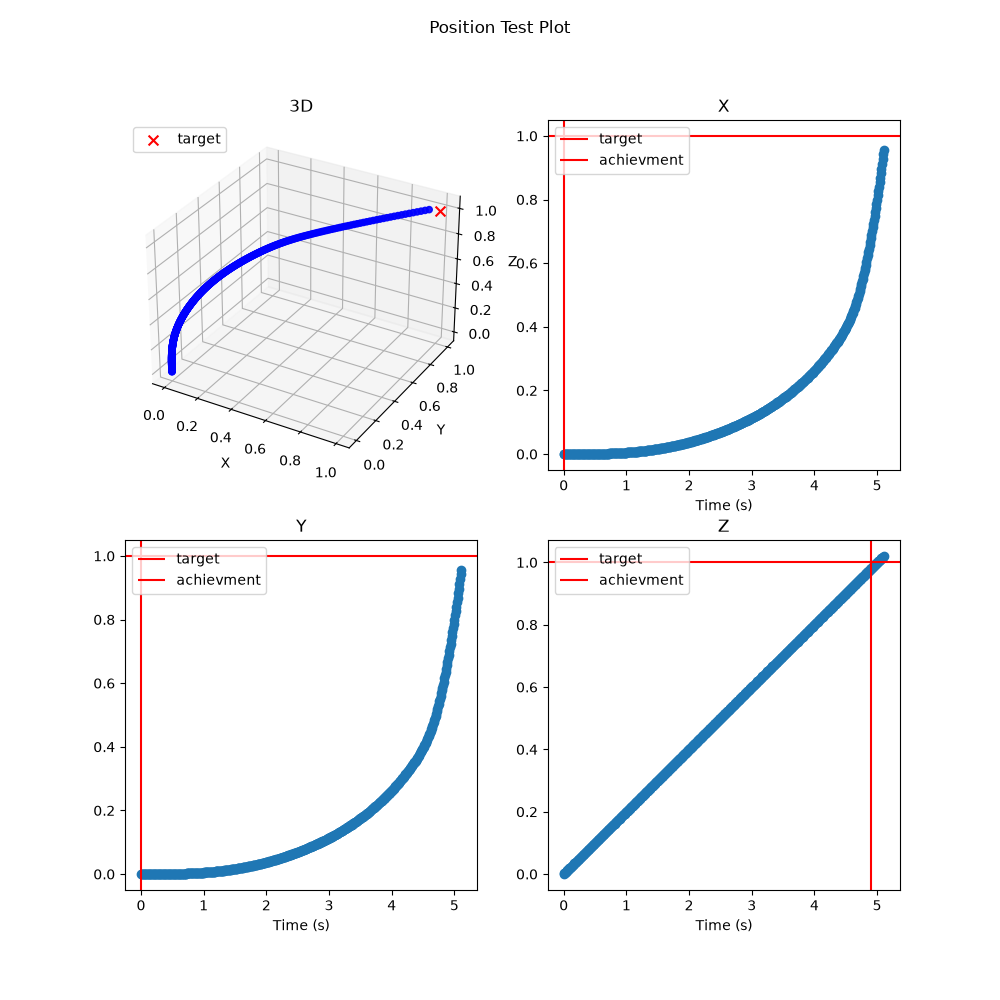

In [7]:
plot_state_vector(
    df['timestep'],
    df['datapoint.position.x'],
    df['datapoint.position.y'],
    df['datapoint.position.z'],
    "Position Test Plot", target=[target_x,target_y,target_z])

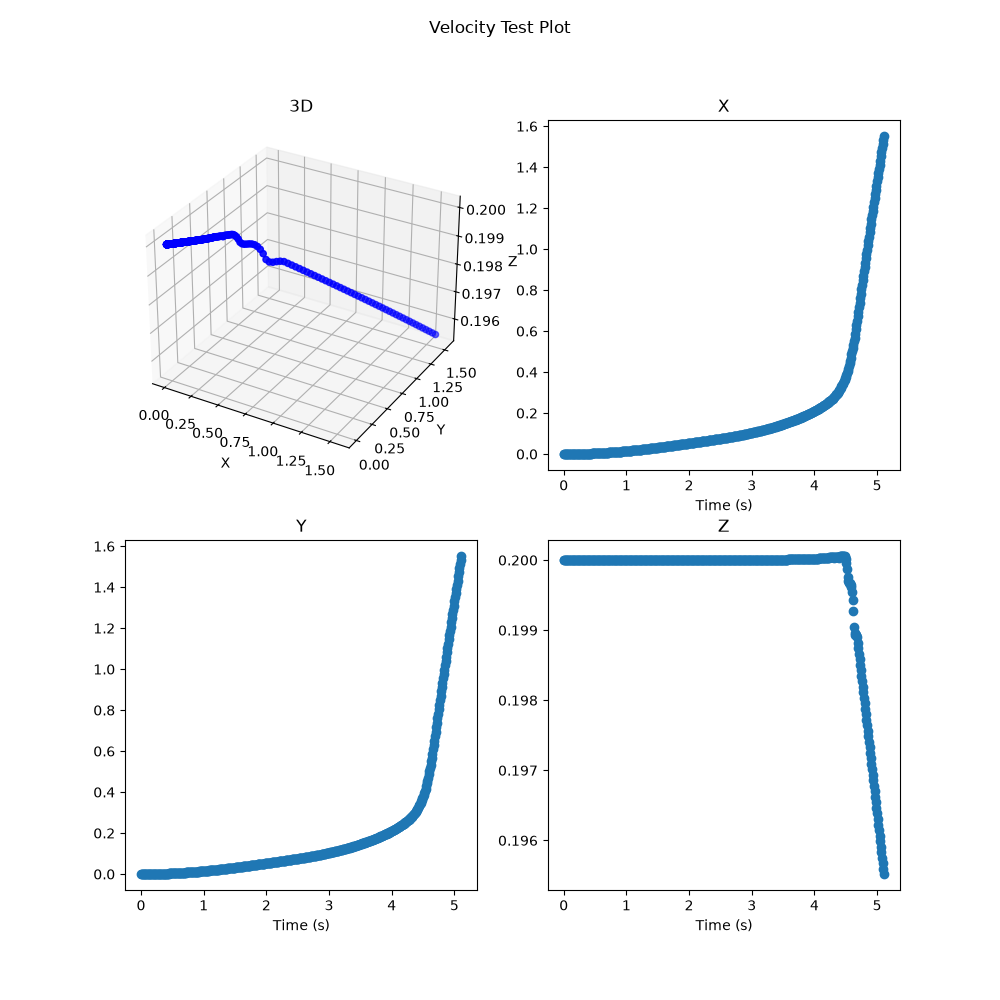

In [8]:
plot_state_vector(
    df['timestep'],
    df['datapoint.velocity.x'],
    df['datapoint.velocity.y'],
    df['datapoint.velocity.z'],
    "Velocity Test Plot")

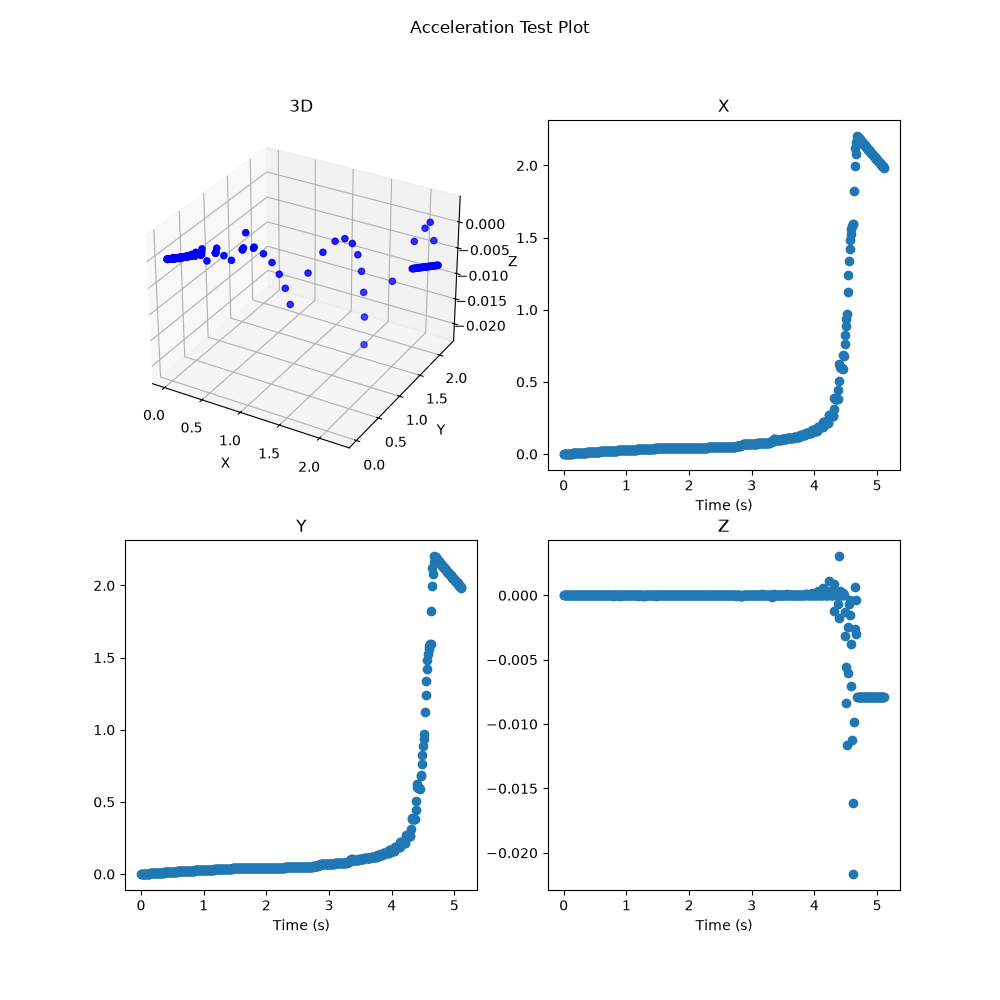

In [9]:
plot_state_vector(
    df['timestep'],
    df['datapoint.acceleration.x'],
    df['datapoint.acceleration.y'],
    df['datapoint.acceleration.z'],
    "Acceleration Test Plot")

In [ ]:
anim_state_vector(
    df['timestep'],
    df['datapoint.position.x'],
    df['datapoint.position.y'],
    df['datapoint.position.z'],
    "Projectile Guidance System Simulation","Position",
    target=[target_x,target_y,target_z])
